In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
csv_file_path = '/content/drive/MyDrive/Colab Notebooks/datascience Lab5/Clean15YearChennaiWeather.csv'
record_set_df = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame
record_set_df

,date,date_id,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
0,"Sunday 14 July 2024, 18.00 — 00.00",1.720980e+12,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,6,18:00,00:00
1,"Monday 15 July 2024, 00.00 — 06.00",1.721002e+12,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,0,00:00,06:00
2,"Monday 15 July 2024, 06.00 — 12.00",1.721023e+12,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,0,06:00,12:00
3,"Monday 15 July 2024, 12.00 — 18.00",1.721045e+12,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,0,12:00,18:00
4,"Monday 15 July 2024, 18.00 — 00.00",1.721066e+12,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,0,18:00,00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,"Saturday 30 January 2010, 18.00 — 00.00",1.264874e+12,10.0,Passing clouds.,26.0,1016.0,76,2010-01-30,1,30,2010,5,18:00,00:00
1064,"Sunday 31 January 2010, 00.00 — 06.00",1.264896e+12,0.0,Clear.,23.0,1015.0,91,2010-01-31,1,31,2010,6,00:00,06:00
1065,"Sunday 31 January 2010, 06.00 — 12.00",1.264918e+12,7.0,Haze.,29.0,1017.0,75,2010-01-31,1,31,2010,6,06:00,12:00
1066,"Sunday 31 January 2010, 12.00 — 18.00",1.264939e+12,16.0,Passing clouds.,29.0,1014.0,55,2010-01-31,1,31,2010,6,12:00,18:00


In [3]:
# Remove if any duplicated data exists
record_set_df = record_set_df.drop_duplicates()
record_set_df

,date,date_id,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
0,"Sunday 14 July 2024, 18.00 — 00.00",1.720980e+12,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,6,18:00,00:00
1,"Monday 15 July 2024, 00.00 — 06.00",1.721002e+12,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,0,00:00,06:00
2,"Monday 15 July 2024, 06.00 — 12.00",1.721023e+12,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,0,06:00,12:00
3,"Monday 15 July 2024, 12.00 — 18.00",1.721045e+12,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,0,12:00,18:00
4,"Monday 15 July 2024, 18.00 — 00.00",1.721066e+12,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,0,18:00,00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,"Saturday 30 January 2010, 18.00 — 00.00",1.264874e+12,10.0,Passing clouds.,26.0,1016.0,76,2010-01-30,1,30,2010,5,18:00,00:00
1064,"Sunday 31 January 2010, 00.00 — 06.00",1.264896e+12,0.0,Clear.,23.0,1015.0,91,2010-01-31,1,31,2010,6,00:00,06:00
1065,"Sunday 31 January 2010, 06.00 — 12.00",1.264918e+12,7.0,Haze.,29.0,1017.0,75,2010-01-31,1,31,2010,6,06:00,12:00
1066,"Sunday 31 January 2010, 12.00 — 18.00",1.264939e+12,16.0,Passing clouds.,29.0,1014.0,55,2010-01-31,1,31,2010,6,12:00,18:00


### 1. Drop Date and Date ID from the Dataset

In [4]:
print("Columns before dropping :", record_set_df.columns)

record_set_df = record_set_df.drop(labels=['date', 'date_id'], axis=1)

print("Columns after dropping :", record_set_df.columns)

Columns before dropping : Index(['date', 'date_id', 'wind', 'desc', 'temp', 'baro', 'hum', 'day',
       'month', 'day_date', 'year', 'day_name', 'Start_hour', 'End_hour'],
      dtype='object')
Columns after dropping : Index(['wind', 'desc', 'temp', 'baro', 'hum', 'day', 'month', 'day_date',
       'year', 'day_name', 'Start_hour', 'End_hour'],
      dtype='object')


### 2. Compute the number of days with Fog, Partly cloudy, Broken clouds, Drizzle and plot the bar graph.

In [5]:
grouped_data = record_set_df.groupby('day')
desc_string = grouped_data.agg({'desc': ' '.join})

weather_dict = desc_string['desc'].to_dict()
weather_dict = {
    day: ". ".join(sorted({x.strip() for x in desc.split('.') if x.strip()}))
    for day, desc in weather_dict.items()
}
weather_dict

{'2009-09-09': 'Clear. No weather data available. Passing clouds',
 '2009-09-10': 'Clear. Passing clouds',
 '2009-09-11': 'Passing clouds',
 '2009-09-12': 'Passing clouds. Scattered clouds',
 '2009-09-13': 'Passing clouds. Scattered clouds',
 '2009-09-14': 'Clear. Passing clouds. Scattered clouds',
 '2009-09-15': 'Partly cloudy. Passing clouds. Thunderstorms',
 '2009-09-16': 'Broken clouds. Passing clouds',
 '2009-09-17': 'Partly cloudy. Passing clouds. Scattered clouds',
 '2009-09-18': 'Passing clouds. Scattered clouds',
 '2009-09-19': 'Broken clouds. Partly cloudy. Partly sunny',
 '2009-09-20': 'Clear. Partly cloudy. Scattered clouds',
 '2009-09-21': 'Passing clouds. Scattered clouds',
 '2009-09-22': 'Passing clouds. Scattered clouds',
 '2009-09-23': 'Partly cloudy. Passing clouds. Scattered clouds. Thunderstorms',
 '2009-09-24': 'Passing clouds. Scattered clouds',
 '2009-09-25': 'No weather data available Sunny. Passing clouds. Scattered clouds',
 '2009-09-26': 'Broken clouds. Passi

{'Fog': 47, 'Partly cloudy': 43, 'Broken clouds': 57, 'Drizzle': 13} 
 --------------------------------------------------


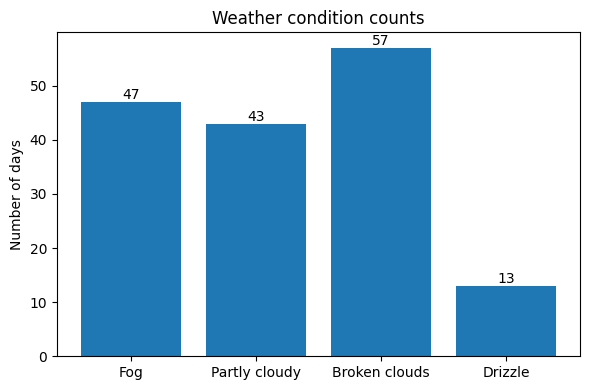

In [6]:
# Goal is to first select days with Fog, Partly cloudy, Broken clouds, Drizzle (4 wether condition)
result_dict = {"Fog":0, "Partly cloudy":0, "Broken clouds":0, "Drizzle":0}

for k, v in weather_dict.items():
  if "Fog" in v:
    result_dict["Fog"] += 1
  if "Partly cloudy" in v:
    result_dict["Partly cloudy"] += 1
  if "Broken clouds" in v:
    result_dict["Broken clouds"] += 1
  if "Drizzle" in v:
    result_dict["Drizzle"] += 1

print(result_dict, '\n', '-'*50)

labels = list(result_dict.keys())
values = list(result_dict.values())

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)
for bar in bars:
    height = bar.get_height()
    plt.text( bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom', fontsize=10)
plt.title("Weather condition counts")
plt.ylabel("Number of days")
plt.tight_layout()
plt.show()



### 3. Compute the average temperature in each year and plot the results as average temperature vs year.

{2009: 29.1526, 2010: 26.7016, 2024: 32.2459} 
 --------------------------------------------------


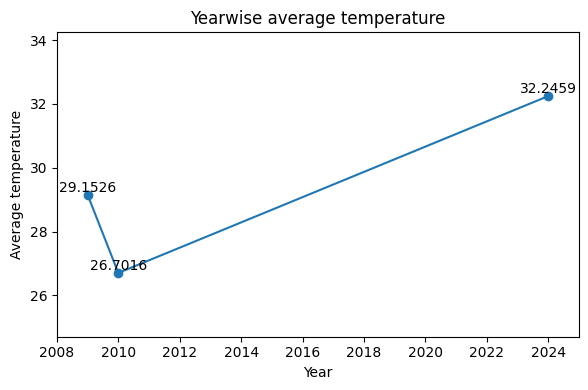

In [7]:
grouped_data = record_set_df.groupby('year')
avg_temp = grouped_data["temp"].mean().round(4)
avg_temp_dict = avg_temp.to_dict()

print(avg_temp_dict, '\n', '-'*50)

labels = sorted(list(avg_temp_dict.keys()))
values = [avg_temp_dict[y] for y in labels]

plt.figure(figsize=(6,4))
plt.plot(labels, values, marker='o')
for x, y in zip(labels, values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=10)
plt.title("Yearwise average temperature")
plt.xlabel("Year")
plt.ylabel("Average temperature")
plt.xlim(min(labels) - 1, max(labels) + 1)
plt.ylim(min(values) - 2, max(values) + 2)
plt.tight_layout()
plt.show()

### 4. Plot histogram for humidity

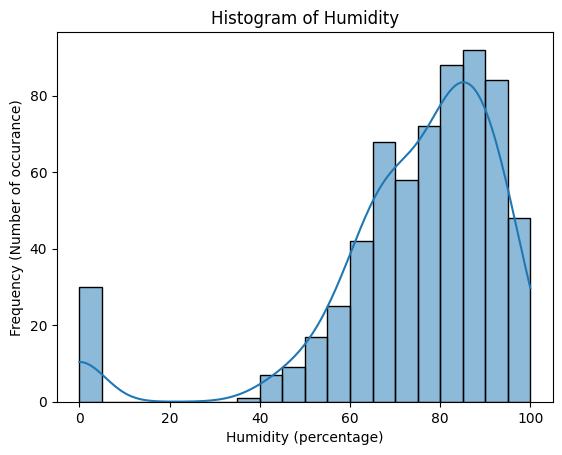

In [8]:
humidity_values = record_set_df['hum'].dropna().to_list()

sns.histplot(data=humidity_values, bins=20, kde=True)
plt.title("Histogram of Humidity")
plt.xlabel("Humidity (percentage)")
plt.ylabel("Frequency (Number of occurance)")
plt.show()

### 5. Plot freq polygon of humidity and temp like above for each year.

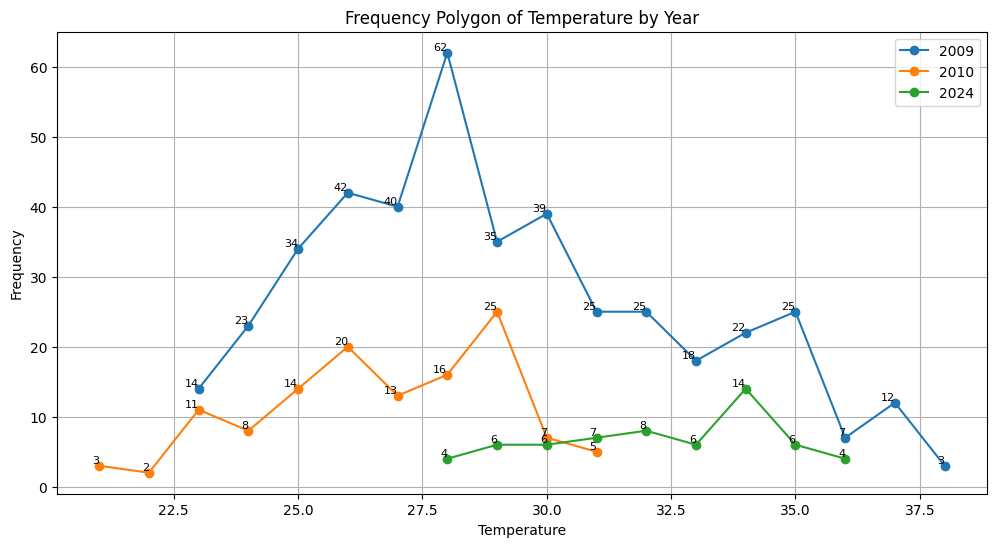

In [9]:
years = sorted(record_set_df['year'].dropna().unique())

plt.figure(figsize=(12, 6))
for y in years:
    sub = record_set_df[record_set_df['year'] == y]
    data = sub["temp"].to_list()
    values, counts = np.unique(data, return_counts=True)
    plt.plot(values, counts, marker='o', label=f"{y}")

    for v, c in zip(values, counts):
        plt.text(v, c, str(c), ha='right', va='bottom', fontsize=8)

plt.title("Frequency Polygon of Temperature by Year")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.grid()
plt.legend()
plt.show()

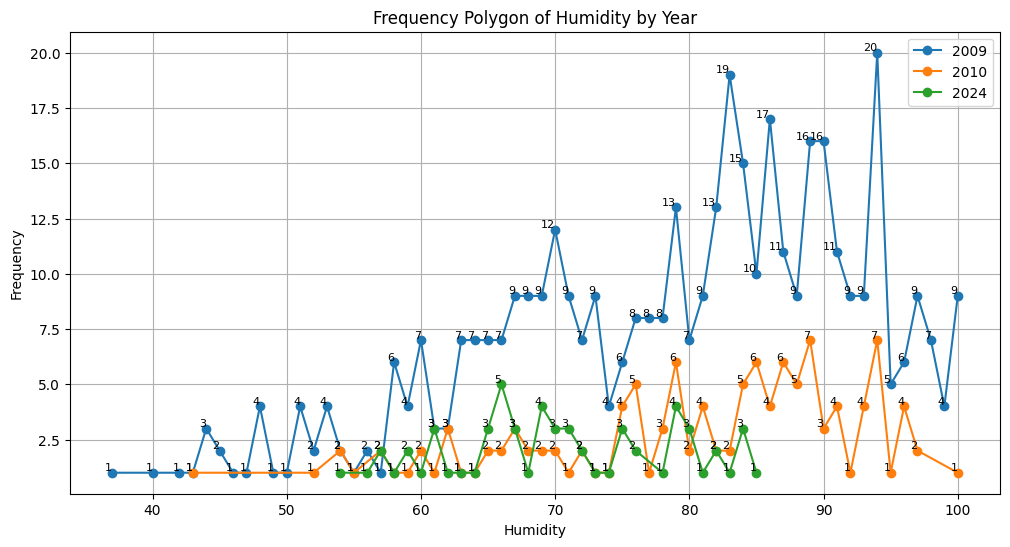

In [10]:
years = sorted(record_set_df['year'].dropna().unique())

plt.figure(figsize=(12, 6))
for y in years:
    sub = record_set_df[record_set_df['year'] == y]
    data = sub["hum"].dropna()
    values, counts = np.unique(data, return_counts=True)
    mask = values != 0
    values = values[mask]
    counts = counts[mask]
    plt.plot(values, counts, marker='o', label=f"{y}")

    for v, c in zip(values, counts):
        plt.text(v, c, str(c), ha='right', va='bottom', fontsize=8)

plt.title("Frequency Polygon of Humidity by Year")
plt.xlabel("Humidity")
plt.ylabel("Frequency")
plt.grid()
plt.legend()
plt.show()

### 6. Compute Mode value desc.

In [11]:
raw_dict = record_set_df['desc'].value_counts().to_dict()

counts = {}   # normal dict, no collections

for desc, value in raw_dict.items():
    # Split into individual labels
    parts = [p.strip() for p in desc.split('.') if p.strip() != ""]

    for label in parts:
        if label in counts:
            counts[label] += value
        else:
            counts[label] = value

# Print result
counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
for i, (label, total) in enumerate(counts):
    print(f"{label}: {total}")

print('-'*50)
print("Mode of col desc is", counts[0])

Passing clouds: 205
Scattered clouds: 121
Broken clouds: 75
Fog: 65
Partly cloudy: 56
Haze: 45
No weather data available: 30
Drizzle: 14
More clouds than sun: 12
Partly sunny: 10
Clear: 9
Light rain: 9
Mostly cloudy: 9
Thunderstorms: 8
Rain: 5
Smoke: 2
Thundershowers: 1
Sunny: 1
Overcast: 1
--------------------------------------------------
Mode of col desc is ('Passing clouds', 205)


### 7. Convert day name as 0: sunday 1: Monday and so on.

In [12]:
# Note as per the data set, 0 is mapped to monday. The above question is wrong, hence moving ahead with below mapping
mapping = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursaday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

record_set_df['day_name'] = record_set_df['day_name'].map(mapping)
record_set_df.head(15)

,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
0,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,Sunday,18:00,00:00
1,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,Monday,00:00,06:00
2,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,Monday,06:00,12:00
3,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,Monday,12:00,18:00
4,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,Monday,18:00,00:00
5,21.0,Fog.,28.0,1001.0,84,2024-07-16,7,16,2024,Tuesday,00:00,06:00
6,21.0,Broken clouds.,31.0,1003.0,79,2024-07-16,7,16,2024,Tuesday,06:00,12:00
7,18.0,Broken clouds.,32.0,1001.0,70,2024-07-16,7,16,2024,Tuesday,12:00,18:00
8,19.0,Drizzle. Fog.,31.0,1002.0,76,2024-07-16,7,16,2024,Tuesday,18:00,00:00
9,17.0,Fog.,29.0,1002.0,83,2024-07-17,7,17,2024,Wednesday,00:00,06:00


### 8. Plot average temperature on Sundays

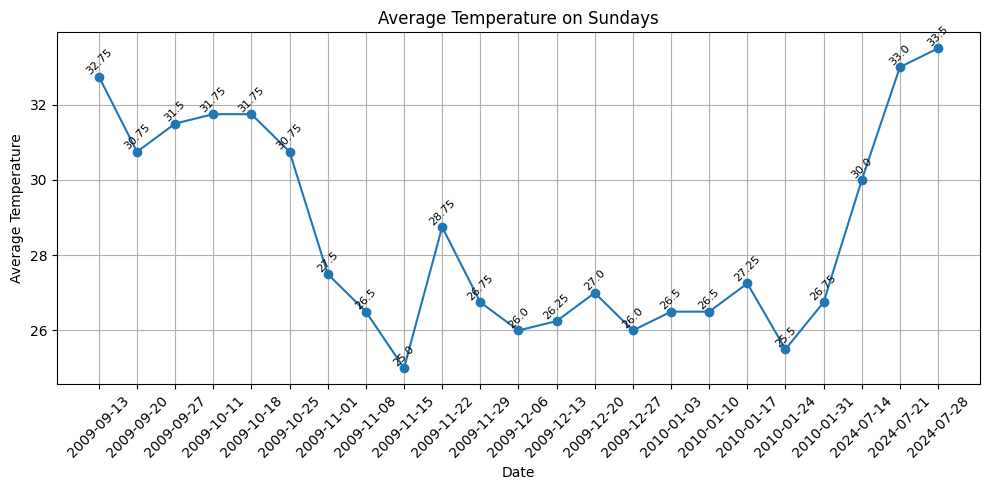

In [13]:
filtered_days_df = record_set_df[record_set_df['day_name'] == 'Sunday']
grouped_data = filtered_days_df.groupby('day')

average_temp_on_sunday = grouped_data["temp"].mean().round(2).dropna()

avg = average_temp_on_sunday
plt.figure(figsize=(10,5))
plt.plot(avg.index, avg.values, marker='o')

# Add value labels
for x, y in zip(avg.index, avg.values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8, rotation=45)

plt.title("Average Temperature on Sundays")
plt.xlabel("Date")
plt.ylabel("Average Temperature")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

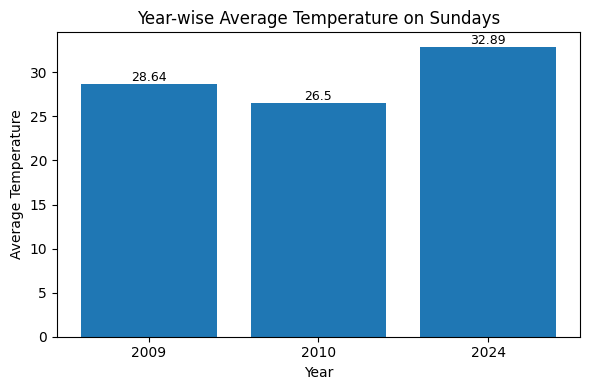

In [14]:
yearly_avg_on_sundays = filtered_days_df.groupby('year')['temp'].mean().round(2).sort_index()

plt.figure(figsize=(6,4))
plt.bar(yearly_avg_on_sundays.index.astype(str), yearly_avg_on_sundays.values)
for x, y in zip(yearly_avg_on_sundays.index.astype(str), yearly_avg_on_sundays.values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=9)
plt.title("Year-wise Average Temperature on Sundays")
plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.tight_layout()
plt.show()

### 9. Plot a pie chart for barometer value <1001 on sundays.

{1000.0: 2, 917.0: 1}
--------------------------------------------------


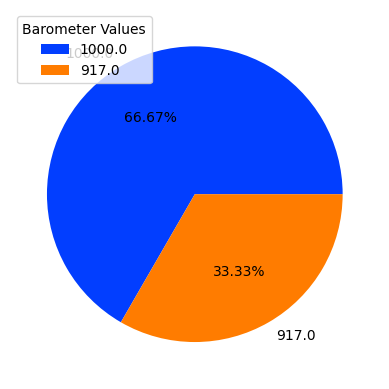

In [20]:
barometer_df = filtered_days_df[filtered_days_df['baro'] < 1001]
barometer_data = barometer_df['baro'].to_list()

freq_dict = {}
for d in barometer_data:
    freq_dict[d] = freq_dict.get(d, 0) + 1

# Remove entries with 0 frequency
freq_dict = {k: v for k, v in freq_dict.items() if k != 0}

print(freq_dict)
print('-' * 50)

data = list(freq_dict.values())
labels = list(freq_dict.keys())

colors = sns.color_palette('bright')
plt.pie(data, labels=labels, colors=colors, autopct='%.2f%%')
plt.legend(labels, title="Barometer Values", loc="upper left")
plt.show()

### 10.Plot which date and month has more reading in each year.

In [16]:
grouped_month = record_set_df.groupby(['year', 'month']).size()
grouped_month

year  month
2009  9         88
      10       124
      11       120
      12       124
2010  1        124
2024  7         61
dtype: int64

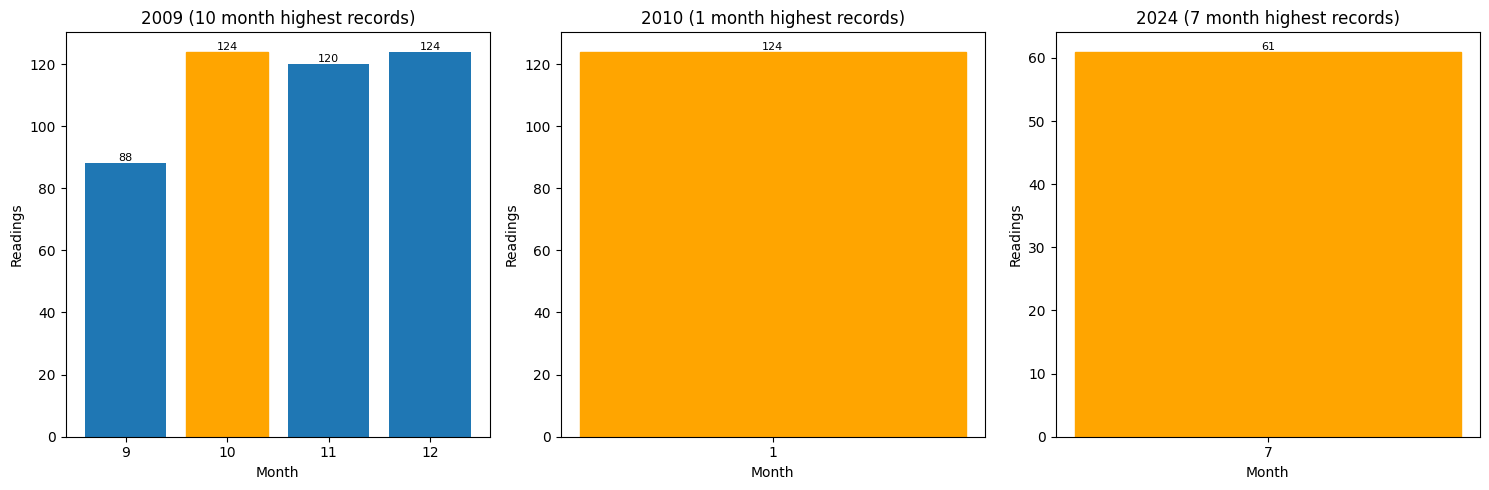

In [17]:
plt.figure(figsize=(15, 5))

years = sorted(record_set_df['year'].unique())

for i, yr in enumerate(years, 1):
    sub = record_set_df[record_set_df['year'] == yr]
    month_counts = sub['month'].value_counts().sort_index()
    max_month = month_counts.idxmax()

    plt.subplot(1, len(years), i)
    bars = plt.bar(month_counts.index, month_counts.values)

    # highlight max month
    bars[list(month_counts.index).index(max_month)].set_color('orange')

    # add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 str(int(height)),
                 ha='center', va='bottom', fontsize=8)

    plt.title(f"{yr} ({max_month} month highest records)")
    plt.xlabel("Month")
    plt.ylabel("Readings")
    plt.xticks(month_counts.index)

plt.tight_layout()
plt.show()


In [18]:
date_counts = record_set_df.groupby(['year', 'day']).size()

top_dates = date_counts.groupby('year').idxmax()   # gives (year, day)
top_counts = date_counts.groupby('year').max()     # gives count

for year in top_dates.index:
    yr, day = top_dates[year]
    count = top_counts[year]
    print(f"Year: {year}, Day: {day}, Records: {count}")


Year: 2009, Day: 2009-09-09, Records: 4
Year: 2010, Day: 2010-01-01, Records: 4
Year: 2024, Day: 2024-07-15, Records: 4


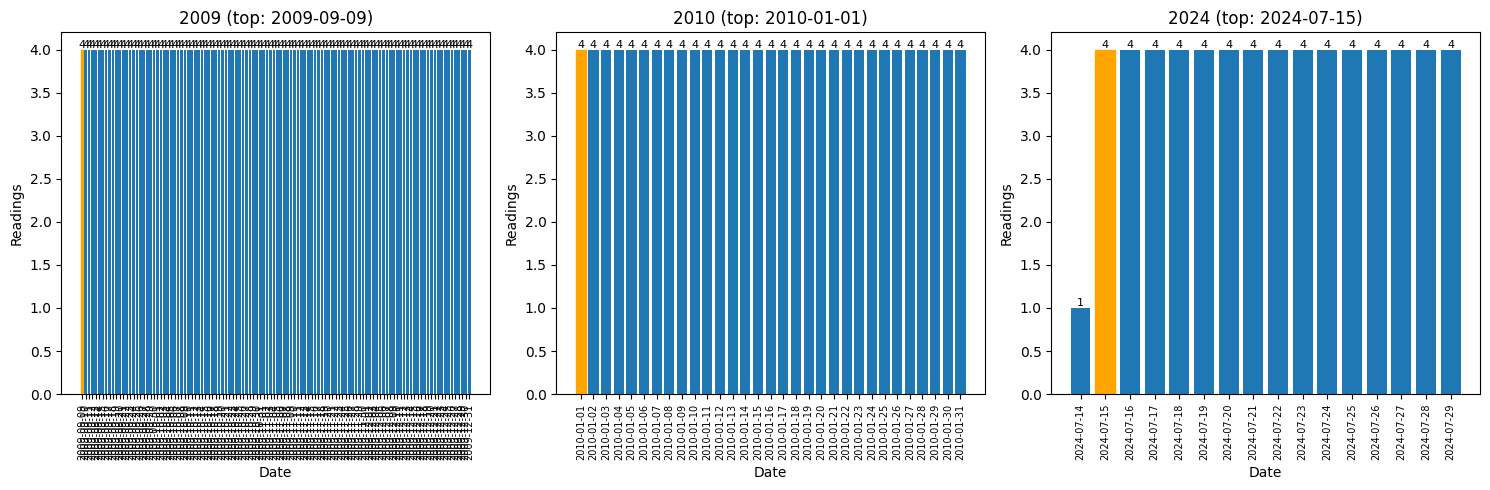

In [19]:
plt.figure(figsize=(15, 5))

years = sorted(record_set_df['year'].unique())

for i, yr in enumerate(years, 1):
    sub = record_set_df[record_set_df['year'] == yr]
    date_counts = sub['day'].value_counts().sort_index()   # day_date = 'YYYY-MM-DD'

    max_date = date_counts.idxmax()

    plt.subplot(1, len(years), i)
    bars = plt.bar(date_counts.index, date_counts.values)

    # highlight the top date
    bars[list(date_counts.index).index(max_date)].set_color('orange')

    # add values on top of bars
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h, str(int(h)),
                 ha='center', va='bottom', fontsize=8)

    plt.title(f"{yr} (top: {max_date})")
    plt.xlabel("Date")
    plt.ylabel("Readings")
    plt.xticks(date_counts.index, rotation=90, fontsize=7)

plt.tight_layout()
plt.show()
